<div style='text-align:center;'>
  <img src="mediacrest.PNG" width="1200">
</div>

<div style="text-align: center; font-weight: bold; font-size: 22px; color: #1a1a1a;">
  <div style="color: #0B5394; font-size: 38px;">MEDIACREST TRAINING COLLEGE</div>
  <div style="color: #38761D; font-size: 24px;">DATA ANALYSIS AND FUNDAMENTALS OF ARTIFICIAL INTELLIGENCE</div>
  <div style="color: #351C75; font-size: 18px;">HYPOTHESIS TESTING AND STATISTICAL INFERENCE</div>
  <br>
  <div style="color: #CC0000; font-size: 22px;">FACILITATOR:</div>
  <div style="color: #000000; font-size: 20px;">VICTOR WANDERA LUMUMBA</div>
  <div style="color: #3D85C6; font-size: 20px;">Mediacrest Training College, Kenya</div>
  <br>
  <div style="color: #6AA84F; font-size: 18px;">Date:</div>
  <div style="color: #351C75; font-size: 18px;">May 4th, 2026</div>
</div>

### **OBJECTIVES**
1. Perform One-Sample, Independent, and Paired T-Tests.
2. Conduct One-Way and Two-Way ANOVA.
3. Check assumptions (Normality, Homogeneity of Variance).
4. Calculate Effect Sizes (Cohen's d, Eta-squared).
5. Interpret results in a medical context.

### **DATASET**
* medical_data_1200.csv

Variables of Interest:
- Continuous: Systolic_BP, Cholesterol, BMI, Heart_Rate, Glucose
- Categorical: Gender (Male/Female), Treatment_Group (Control/Drug_A/Drug_B)

### **Load the Required Libraries**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import pingouin as pg  # Excellent library for biomedical stats & effect sizes
import warnings
warnings.filterwarnings('ignore')

### **Set plotting style**

In [20]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### **Load the Data and Inspect it**

In [21]:
print("Loading data...")
df = pd.read_csv('medical_data_1200.csv')
df.head(10)

Loading data...


,ID,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Cholesterol,Glucose,Treatment_Group,Hypertension,Diabetes_Risk,Smoker,Stress_Level
0,1,47,Female,30.5,187.7,128.4,82.1,261.7,116.9,Control,Yes,High,No,8
1,2,55,Female,21.8,173.1,117.1,71.7,248.6,110.6,Drug_B,Yes,Low,Yes,4
2,3,62,Male,26.3,186.2,126.4,72.0,264.7,111.9,Control,Yes,Low,No,2
3,4,60,Female,22.1,167.8,113.3,83.2,261.3,111.9,Drug_A,Yes,Low,No,4
4,5,42,Female,24.1,175.9,118.7,79.2,238.1,111.8,Control,Yes,Low,No,4
5,6,69,Female,25.2,200.1,125.1,78.5,297.8,122.9,Control,Yes,Low,No,7
6,7,31,Female,24.0,186.5,112.3,75.5,234.4,100.5,Control,Yes,Low,No,3
7,8,60,Male,24.4,184.8,130.8,64.8,274.7,109.6,Drug_A,Yes,Low,No,6
8,9,44,Female,22.4,175.9,111.3,81.8,239.4,101.1,Control,Yes,Low,Yes,7
9,10,27,Female,24.7,155.9,109.7,65.6,188.6,105.2,Drug_B,Yes,Low,No,7


### **Check the Data Structure**

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               1200 non-null   int64  
 1   Age              1200 non-null   int64  
 2   Gender           1200 non-null   object 
 3   BMI              1200 non-null   float64
 4   Systolic_BP      1200 non-null   float64
 5   Diastolic_BP     1200 non-null   float64
 6   Heart_Rate       1200 non-null   float64
 7   Cholesterol      1200 non-null   float64
 8   Glucose          1200 non-null   float64
 9   Treatment_Group  1200 non-null   object 
 10  Hypertension     1200 non-null   object 
 11  Diabetes_Risk    1200 non-null   object 
 12  Smoker           1200 non-null   object 
 13  Stress_Level     1200 non-null   int64  
dtypes: float64(6), int64(3), object(5)
memory usage: 131.4+ KB


### **Ensure categorical variables are treated as such**

In [23]:
df['Gender'] = df['Gender'].astype('category')
df['Treatment_Group'] = df['Treatment_Group'].astype('category')
df['Hypertension'] = df['Hypertension'].astype('category')
df['Diabetes_Risk'] = df['Diabetes_Risk'].astype('category')
df['Smoker'] = df['Smoker'].astype('category')

### **Display first few rows and info**

In [24]:
print("\n--- Data Head ---")
df.head()


--- Data Head ---


,ID,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Cholesterol,Glucose,Treatment_Group,Hypertension,Diabetes_Risk,Smoker,Stress_Level
0,1,47,Female,30.5,187.7,128.4,82.1,261.7,116.9,Control,Yes,High,No,8
1,2,55,Female,21.8,173.1,117.1,71.7,248.6,110.6,Drug_B,Yes,Low,Yes,4
2,3,62,Male,26.3,186.2,126.4,72.0,264.7,111.9,Control,Yes,Low,No,2
3,4,60,Female,22.1,167.8,113.3,83.2,261.3,111.9,Drug_A,Yes,Low,No,4
4,5,42,Female,24.1,175.9,118.7,79.2,238.1,111.8,Control,Yes,Low,No,4


In [25]:
print("\n--- Data Info ---")
print(df.info())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   ID               1200 non-null   int64   
 1   Age              1200 non-null   int64   
 2   Gender           1200 non-null   category
 3   BMI              1200 non-null   float64 
 4   Systolic_BP      1200 non-null   float64 
 5   Diastolic_BP     1200 non-null   float64 
 6   Heart_Rate       1200 non-null   float64 
 7   Cholesterol      1200 non-null   float64 
 8   Glucose          1200 non-null   float64 
 9   Treatment_Group  1200 non-null   category
 10  Hypertension     1200 non-null   category
 11  Diabetes_Risk    1200 non-null   category
 12  Smoker           1200 non-null   category
 13  Stress_Level     1200 non-null   int64   
dtypes: category(5), float64(6), int64(3)
memory usage: 91.0 KB
None


### **2. EXPLORATORY DATA ANALYSIS (Grouped Summary Statistics)**

#### **2.1 Summary by Gender (For Independent T-Test Prep)**

In [29]:
print("\n--- Grouped Summary Statistics ---")


--- Grouped Summary Statistics ---


In [ ]:
print("\nMean BMI and Heart Rate by Gender:")
df.groupby('Gender')[['BMI', 'Heart_Rate']].mean().round(2)

#### **2.2 Summary by Treatment Group (For ANOVA Prep)**

In [27]:
print("\nMean Systolic BP and Cholesterol by Treatment Group:")
df.groupby('Treatment_Group')[['Systolic_BP', 'Cholesterol']].mean().round(2)


Mean Systolic BP and Cholesterol by Treatment Group:


,Systolic_BP,Cholesterol
Treatment_Group,,
Control,182.02,253.66
Drug_A,173.38,256.33
Drug_B,177.31,227.66


#### **2.3 Visualizing Distributions**

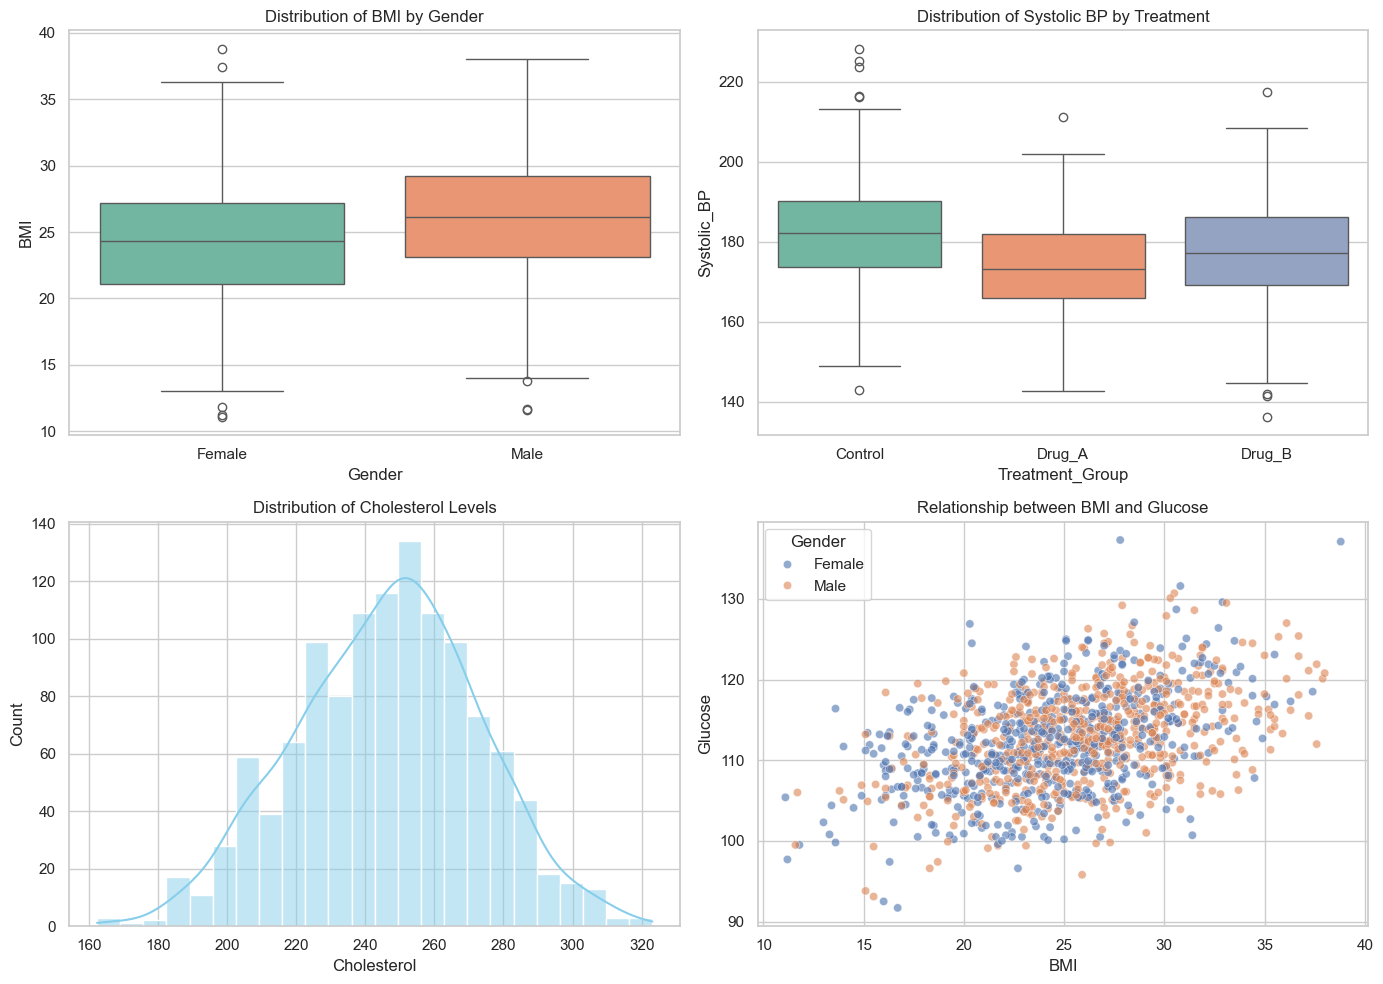

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot: BMI by Gender
sns.boxplot(x='Gender', y='BMI', data=df, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title('Distribution of BMI by Gender')

# Boxplot: Systolic BP by Treatment Group
sns.boxplot(x='Treatment_Group', y='Systolic_BP', data=df, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title('Distribution of Systolic BP by Treatment')

# Histogram: Cholesterol
sns.histplot(df['Cholesterol'], kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Distribution of Cholesterol Levels')

# Scatter: BMI vs Glucose (Correlation check)
sns.scatterplot(x='BMI', y='Glucose', hue='Gender', data=df, ax=axes[1, 1], alpha=0.6)
axes[1, 1].set_title('Relationship between BMI and Glucose')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=300)
plt.show()


### **3. ASSUMPTION CHECKING**

#### **Assumption 1: Normality (Shapiro-Wilk Test)**
* Note: With N=1200, Shapiro-Wilk is very sensitive. We also look at Q-Q plots.

In [30]:
print("\n" + "="*60)
print("SECTION 3: ASSUMPTION CHECKING")
print("="*60)

def check_normality(data, group_name):
    stat, p = stats.shapiro(data)
    print(f"Shapiro-Wilk Test for {group_name}: Stat={stat:.3f}, p-value={p:.4f}")
    if p > 0.05:
        print("-> Conclusion: Fail to reject H0 (Data is likely Normal)")
    else:
        print("-> Conclusion: Reject H0 (Data deviates from Normality)")
    return p

print("\n--- Normality Checks ---")
# Check BMI for Males and Females separately
male_bmi = df[df['Gender'] == 'Male']['BMI']
female_bmi = df[df['Gender'] == 'Female']['BMI']
check_normality(male_bmi, "Male BMI")
check_normality(female_bmi, "Female BMI")

# Check Systolic BP for each Treatment Group
for group in df['Treatment_Group'].unique():
    subset = df[df['Treatment_Group'] == group]['Systolic_BP']
    check_normality(subset, f"Systolic BP ({group})")


SECTION 3: ASSUMPTION CHECKING

--- Normality Checks ---
Shapiro-Wilk Test for Male BMI: Stat=0.998, p-value=0.5584
-> Conclusion: Fail to reject H0 (Data is likely Normal)
Shapiro-Wilk Test for Female BMI: Stat=0.998, p-value=0.8747
-> Conclusion: Fail to reject H0 (Data is likely Normal)
Shapiro-Wilk Test for Systolic BP (Control): Stat=0.996, p-value=0.4191
-> Conclusion: Fail to reject H0 (Data is likely Normal)
Shapiro-Wilk Test for Systolic BP (Drug_B): Stat=0.997, p-value=0.6103
-> Conclusion: Fail to reject H0 (Data is likely Normal)
Shapiro-Wilk Test for Systolic BP (Drug_A): Stat=0.997, p-value=0.7189
-> Conclusion: Fail to reject H0 (Data is likely Normal)


### **Assumption 2: Homogeneity of Variance (Levene's Test)**

In [31]:
print("\n--- Homogeneity of Variance (Levene's Test) ---")

# For T-Test: BMI across Gender
stat_levene, p_levene = stats.levene(male_bmi, female_bmi)
print(f"Levene's Test (BMI by Gender): Stat={stat_levene:.3f}, p-value={p_levene:.4f}")
if p_levene > 0.05:
    print("-> Variances are equal (Use Student's T-Test)")
else:
    print("-> Variances are unequal (Use Welch's T-Test)")

# For ANOVA: Systolic BP across Treatment Groups
control_bp = df[df['Treatment_Group'] == 'Control']['Systolic_BP']
drug_a_bp = df[df['Treatment_Group'] == 'Drug_A']['Systolic_BP']
drug_b_bp = df[df['Treatment_Group'] == 'Drug_B']['Systolic_BP']

stat_levene_anova, p_levene_anova = stats.levene(control_bp, drug_a_bp, drug_b_bp)
print(f"Levene's Test (Systolic BP by Treatment): Stat={stat_levene_anova:.3f}, p-value={p_levene_anova:.4f}")
if p_levene_anova > 0.05:
    print("-> Variances are equal (Standard ANOVA is valid)")
else:
    print("-> Variances are unequal (Consider Welch's ANOVA)")


--- Homogeneity of Variance (Levene's Test) ---
Levene's Test (BMI by Gender): Stat=0.065, p-value=0.7988
-> Variances are equal (Use Student's T-Test)
Levene's Test (Systolic BP by Treatment): Stat=1.113, p-value=0.3289
-> Variances are equal (Standard ANOVA is valid)


#### **4. T-TESTS**

In [32]:
print("\n" + "="*60)
print("SECTION 4: T-TESTS")
print("="*60)

# 4.1 One-Sample T-Test
# Question: Is the mean Systolic BP of the Control group different from the standard healthy value of 120 mmHg?
control_group = df[df['Treatment_Group'] == 'Control']
pop_mean_standard = 120

t_stat_1, p_val_1 = stats.ttest_1samp(control_group['Systolic_BP'], popmean=pop_mean_standard)
print(f"\n4.1 One-Sample T-Test (Control BP vs 120 mmHg)")
print(f"Sample Mean: {control_group['Systolic_BP'].mean():.2f}")
print(f"t-statistic: {t_stat_1:.3f}, p-value: {p_val_1:.4f}")
if p_val_1 < 0.05:
    print("Result: Significant difference from 120 mmHg.")
else:
    print("Result: No significant difference from 120 mmHg.")


SECTION 4: T-TESTS

4.1 One-Sample T-Test (Control BP vs 120 mmHg)
Sample Mean: 182.02
t-statistic: 101.928, p-value: 0.0000
Result: Significant difference from 120 mmHg.


#### **4.2 Independent Samples T-Test**
* Question: Is there a difference in Mean BMI between Males and Females?

* Check Levene's result from earlier to decide equal_var parameter

Based on the results above, variances are similar across groups

In [33]:
t_stat_ind, p_val_ind = stats.ttest_ind(male_bmi, female_bmi, equal_var=False) # Welch's T-Test
print(f"\n4.2 Independent Samples T-Test (BMI: Male vs Female)")
print(f"Male Mean BMI: {male_bmi.mean():.2f}")
print(f"Female Mean BMI: {female_bmi.mean():.2f}")
print(f"t-statistic: {t_stat_ind:.3f}, p-value: {p_val_ind:.4f}")


4.2 Independent Samples T-Test (BMI: Male vs Female)
Male Mean BMI: 26.04
Female Mean BMI: 24.24
t-statistic: 6.734, p-value: 0.0000


In [34]:
# Calculate Effect Size (Cohen's d) using Pingouin
cohens_d = pg.compute_effsize(male_bmi, female_bmi, eftype='cohen')
print(f"Cohen's d: {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    effect_interp = "Negligible"
elif abs(cohens_d) < 0.5:
    effect_interp = "Small"
elif abs(cohens_d) < 0.8:
    effect_interp = "Medium"
else:
    effect_interp = "Large"
print(f"Interpretation: {effect_interp} effect size.")

Cohen's d: 0.389
Interpretation: Small effect size.


### **5. ONE-WAY ANOVA**

* Research Question: Does Treatment Group affect Systolic Blood Pressure?

- H0: Mean(Control) = Mean(Drug_A) = Mean(Drug_B)
- H1: At least one mean is different


In [37]:
print("\n" + "="*60)
print("SECTION 5: ONE-WAY ANOVA")
print("="*60)

# Using Pingouin for a clean ANOVA table and effect size
anova_result = pg.anova(data=df, dv='Systolic_BP', between='Treatment_Group', detailed=True)
print("\n5.1 One-Way ANOVA Table (Systolic BP ~ Treatment Group)")
anova_result


SECTION 5: ONE-WAY ANOVA

5.1 One-Way ANOVA Table (Systolic BP ~ Treatment Group)


,Source,SS,DF,MS,F,p_unc,np2
0,Treatment_Group,15482.909399,2,7741.454700,49.152262,3.053355e-21,0.075893
1,Within,188526.852192,1197,157.499459,NaN,NaN,NaN


#### **6. TWO-WAY ANOVA**

* Research Question: Do Treatment Group AND Gender affect Cholesterol levels?
* Is there an interaction effect? (e.g., Does Drug B work differently for Men vs Women?)

In [43]:
print("\n" + "="*60)
print("SECTION 6: TWO-WAY ANOVA")
print("="*60)

# Using StatsModels for Two-Way ANOVA
model_formula = 'Cholesterol ~ C(Treatment_Group) * C(Gender)'
model = ols(model_formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n6.1 Two-Way ANOVA Table (Cholesterol ~ Treatment * Gender)")
anova_table


SECTION 6: TWO-WAY ANOVA

6.1 Two-Way ANOVA Table (Cholesterol ~ Treatment * Gender)


,sum_sq,df,F,PR(>F)
C(Treatment_Group),190704.960958,2.0,172.954847,1.088722e-66
C(Gender),42.791449,1.0,0.077617,7.806012e-01
C(Treatment_Group):C(Gender),1292.641887,2.0,1.172328,3.100015e-01
Residual,658269.275103,1194.0,NaN,NaN


In [44]:
# Interpretation
trt_p = anova_table['PR(>F)']['C(Treatment_Group)']
gen_p = anova_table['PR(>F)']['C(Gender)']
inter_p = anova_table['PR(>F)']['C(Treatment_Group):C(Gender)']

print(f"\nP-value (Treatment Main Effect): {trt_p:.4f}")
print(f"P-value (Gender Main Effect): {gen_p:.4f}")
print(f"P-value (Interaction Effect): {inter_p:.4f}")


P-value (Treatment Main Effect): 0.0000
P-value (Gender Main Effect): 0.7806
P-value (Interaction Effect): 0.3100


In [45]:
if inter_p < 0.05:
    print("Conclusion: Significant Interaction Effect. The effect of Treatment on Cholesterol depends on Gender.")
    print("Recommendation: Analyze simple main effects (split by gender).")
else:
    print("Conclusion: No Significant Interaction. Interpret Main Effects independently.")
    if trt_p < 0.05:
        print("- Treatment has a significant main effect on Cholesterol.")
    if gen_p < 0.05:
        print("- Gender has a significant main effect on Cholesterol.")


Conclusion: No Significant Interaction. Interpret Main Effects independently.
- Treatment has a significant main effect on Cholesterol.


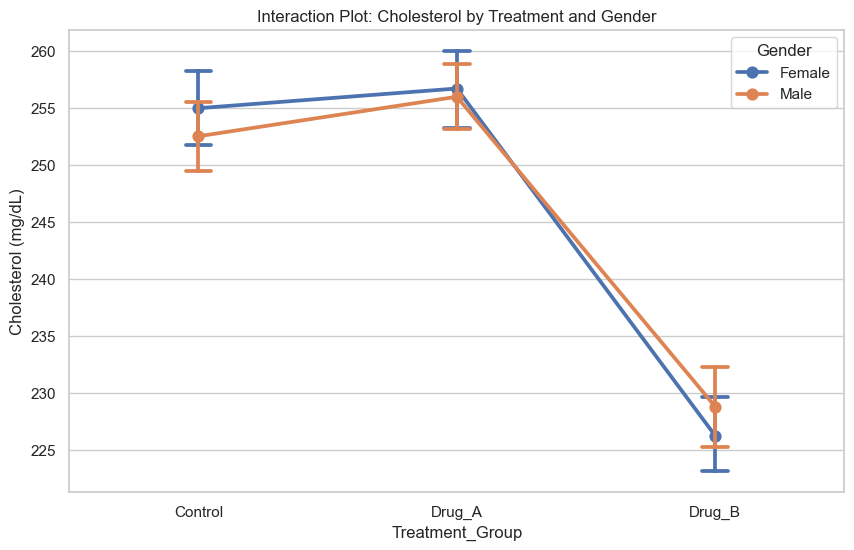

In [46]:
### Interaction Plot
plt.figure(figsize=(10, 6))
sns.pointplot(x='Treatment_Group', y='Cholesterol', hue='Gender', data=df, capsize=.1)
plt.title('Interaction Plot: Cholesterol by Treatment and Gender')
plt.ylabel('Cholesterol (mg/dL)')
plt.savefig('interaction_plot.png', dpi=300)
plt.show()

#### **7. SUMMARY REPORT GENERATION**

In [47]:
print("\n" + "="*60)
print("FINAL SUMMARY FOR REPORT")
print("="*60)

summary_text = f"""
STATISTICAL ANALYSIS REPORT
---------------------------
1. Independent T-Test (BMI by Gender):
   - t-stat: {t_stat_ind:.3f}, p-value: {p_val_ind:.4f}
   - Cohen's d: {cohens_d:.3f} ({effect_interp})
   - Decision: {'Reject H0' if p_val_ind < 0.05 else 'Fail to Reject H0'}

2. One-Way ANOVA (Systolic BP by Treatment):
   - F-stat: {f_val:.3f}, p-value: {p_val_anova:.4f}
   - Eta-Squared: {eta_sq:.3f}
   - Decision: {'Reject H0' if p_val_anova < 0.05 else 'Fail to Reject H0'}
   - Post-Hoc: See Tukey HSD table above.

3. Two-Way ANOVA (Cholesterol ~ Treatment * Gender):
   - Interaction P-value: {inter_p:.4f}
   - Decision: {'Significant Interaction' if inter_p < 0.05 else 'No Interaction'}
"""

print(summary_text)

# Save summary to text file
with open('analysis_summary.txt', 'w') as f:
    f.write(summary_text)

print("\nAnalysis complete. Plots and summary saved.")


FINAL SUMMARY FOR REPORT

STATISTICAL ANALYSIS REPORT
---------------------------
1. Independent T-Test (BMI by Gender):
   - t-stat: 6.734, p-value: 0.0000
   - Cohen's d: 0.389 (Small)
   - Decision: Reject H0

2. One-Way ANOVA (Systolic BP by Treatment):
   - F-stat: 49.152, p-value: 0.0000
   - Eta-Squared: 0.076
   - Decision: Reject H0
   - Post-Hoc: See Tukey HSD table above.

3. Two-Way ANOVA (Cholesterol ~ Treatment * Gender):
   - Interaction P-value: 0.3100
   - Decision: No Interaction


Analysis complete. Plots and summary saved.
